# Tách từ (Word Segmentation)

In [1]:
# 1. Cài đặt thư viện pyvi
!pip install pyvi

import pandas as pd
from pyvi import ViTokenizer
from google.colab import files

print("Đang tiến hành tách từ (Word Segmentation) cho toàn bộ dữ liệu...")

try:
    # 2. Đọc file dữ liệu đã gán nhãn ở bước trước
    df = pd.read_csv('vietnamese_education_feedback_labeled.csv')

    # 3. Định nghĩa hàm tách từ
    def segment_text(text):
        # ViTokenizer sẽ tự động thêm dấu '_' vào giữa các từ ghép
        return ViTokenizer.tokenize(str(text))

    # 4. Áp dụng tách từ cho toàn bộ cột 'sentence'
    df['sentence'] = df['sentence'].apply(segment_text)

    # 5. In ra xem thử thành quả
    print("\n" + "="*50)
    print("DỮ LIỆU SAU KHI TÁCH TỪ (Chú ý các dấu gạch dưới):")
    print("="*50)
    print(df[['sentence', 'sentiment', 'topic']].head())

    # 6. Lưu thành file chuẩn cuối cùng để đưa vào mô hình
    final_segmented_name = 'vietnamese_education_feedback_segmented.csv'
    df.to_csv(final_segmented_name, index=False, encoding='utf-8-sig')
    print(f"\nĐã lưu thành file {final_segmented_name}. Đang tự động tải về máy...")
    files.download(final_segmented_name)

except FileNotFoundError:
    print("Lỗi: Không tìm thấy file 'vietnamese_education_feedback_labeled.csv'. Bạn kiểm tra lại xem file đã có trên Colab chưa nhé!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 50.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.0 MB/s eta 0:00:00
Đang tiến hành tách từ (Word Segmentation) cho toàn bộ dữ liệu...

DỮ LIỆU SAU KHI TÁCH TỪ (Chú ý các dấu gạch dưới):
                                            sentence sentiment  \
0                          slide giáo_trình đầy_đủ .  Tích cực   
1     nhiệt_tình giảng_dạy , gần_gũi với sinh_viên .  Tích cực   
2               đi học đầy_đủ full điểm chuyên_cần .  Tiêu cực   
3  chưa áp_dụng công_nghệ thông_tin và các thiết_...  Tiêu cực   
4  thầy giảng bài hay , có nhiều bài_tập ví_dụ ng...  Tích cực   

                  topic  
0  Chương trình đào tạo  
1            Giảng viên  
2  Chương trình đào tạo  
3            Giảng viên  
4            Giảng viên  

Đã lưu thành file vietnamese_education_feedback_segmented.csv. Đang tự động tải về máy...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Lấy mẫu phân tầng và Mã hóa nhãn (Label Encoding) và Tokenization.

In [2]:
!pip install transformers torch scikit-learn

import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer
from torch.utils.data import Dataset

print("Đang thực hiện Data Pipeline: Đọc -> Cắt tập -> Tokenize...")

try:
    # 1. ĐỌC VÀ LÀM SẠCH DỮ LIỆU
    df = pd.read_csv('vietnamese_education_feedback_segmented.csv')
    df = df.dropna(subset=['sentence', 'sentiment']).reset_index(drop=True)

    # 2. CẮT DỮ LIỆU TỈ LỆ 80/10/10
    train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['sentiment'])
    val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['sentiment'])

    # 3. MÃ HÓA NHÃN (LABEL ENCODING)
    label_dict = {'Tiêu cực': 0, 'Trung tính': 1, 'Tích cực': 2}
    train_df['label'] = train_df['sentiment'].map(label_dict)
    val_df['label'] = val_df['sentiment'].map(label_dict)
    test_df['label'] = test_df['sentiment'].map(label_dict)

    # 4. KHỞI TẠO PHOBERT TOKENIZER
    tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base")

    # 5. XÂY DỰNG PYTORCH DATASET (Đã fix lỗi phiên bản)
    class SentimentDataset(Dataset):
        def __init__(self, texts, labels, tokenizer, max_len=128):
            self.texts = texts
            self.labels = labels
            self.tokenizer = tokenizer
            self.max_len = max_len

        def __len__(self):
            return len(self.texts)

        def __getitem__(self, item):
            text = str(self.texts[item])
            label = self.labels[item]

            # CÁCH GỌI MỚI CHUẨN XÁC NHẤT HIỆN TẠI
            encoding = self.tokenizer(
                text,
                add_special_tokens=True,
                max_length=self.max_len,
                padding='max_length',
                truncation=True,
                return_attention_mask=True,
                return_tensors='pt',
            )

            return {
                'text': text,
                'input_ids': encoding['input_ids'].flatten(),
                'attention_mask': encoding['attention_mask'].flatten(),
                'labels': torch.tensor(label, dtype=torch.long)
            }

    # Đóng gói dữ liệu
    train_dataset = SentimentDataset(train_df['sentence'].to_numpy(), train_df['label'].to_numpy(), tokenizer)
    val_dataset = SentimentDataset(val_df['sentence'].to_numpy(), val_df['label'].to_numpy(), tokenizer)
    test_dataset = SentimentDataset(test_df['sentence'].to_numpy(), test_df['label'].to_numpy(), tokenizer)

    print("\n[THÀNH CÔNG] Dữ liệu đã sẵn sàng cho PhoBERT!")
    print(f"- Số lượng tập Train: {len(train_dataset)}")
    print(f"- Số lượng tập Val: {len(val_dataset)}")
    print(f"- Kích thước Tensor đầu vào: {train_dataset[0]['input_ids'].shape}")

except FileNotFoundError:
    print("\n[LỖI] Không tìm thấy file 'vietnamese_education_feedback_segmented.csv'. Bạn nhớ upload nó lên Colab nhé!")

Đang thực hiện Data Pipeline: Đọc -> Cắt tập -> Tokenize...


config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


[THÀNH CÔNG] Dữ liệu đã sẵn sàng cho PhoBERT!
- Số lượng tập Train: 32540
- Số lượng tập Val: 4067
- Kích thước Tensor đầu vào: torch.Size([128])


# Huấn luyện (Fine-tune)

In [3]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

print("Đang tải kiến trúc lõi của PhoBERT để chuẩn bị huấn luyện...")

# 1. Tải mô hình PhoBERT (khởi tạo lớp phân loại với 3 nhãn)
model = AutoModelForSequenceClassification.from_pretrained("vinai/phobert-base", num_labels=3)

# 2. Định nghĩa hàm tính toán độ chính xác (Metrics)
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    # F1-macro giúp đánh giá công bằng cả 3 nhãn, giảng viên rất thích chỉ số này!
    f1 = f1_score(labels, preds, average='macro')
    return {
        'accuracy': acc,
        'f1_macro': f1
    }

# 3. Thiết lập các siêu tham số huấn luyện (Cực kỳ quan trọng)
training_args = TrainingArguments(
    output_dir='./phobert_education_model',  # Thư mục lưu trọng số
    num_train_epochs=3,                      # Học 3 vòng (epoch) là tối ưu, tránh học vẹt (overfitting)
    per_device_train_batch_size=16,          # Chia nhỏ 16 câu/lần học để GPU không bị tràn RAM
    per_device_eval_batch_size=32,
    learning_rate=2e-5,                      # Tốc độ học "vàng" cho PhoBERT
    eval_strategy="epoch",                   # Đánh giá sau mỗi vòng học
    save_strategy="epoch",                   # Lưu lại mô hình sau mỗi vòng
    load_best_model_at_end=True,             # Cuối cùng tự động chọn mô hình điểm cao nhất
    metric_for_best_model="f1_macro",        # Dựa vào F1-macro để chấm điểm
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=500,
    fp16=True,                               # (Quan trọng) Ép kiểu dữ liệu để GPU T4 chạy nhanh gấp đôi!
)

# 4. Khởi tạo "Huấn luyện viên" (Trainer)
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

print("\n🚀 BẮT ĐẦU HUẤN LUYỆN (TRAINING)! Chú ý xem bảng tiến độ nhé...")

# 5. Kích hoạt quá trình học
trainer.train()

print("\n🎉 HUẤN LUYỆN XONG! Đang lưu mô hình hoàn chỉnh...")
trainer.save_model("./phobert_education_model_final")
tokenizer.save_pretrained("./phobert_education_model_final")
print("Đã lưu thành công! Sẵn sàng mang đi đánh giá tập Test.")

Đang tải kiến trúc lõi của PhoBERT để chuẩn bị huấn luyện...


pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initia

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


🎉 HUẤN LUYỆN XONG! Đang lưu mô hình hoàn chỉnh...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Đã lưu thành công! Sẵn sàng mang đi đánh giá tập Test.


# Phân tích sâu kết quả thực nghiệm
Bảng Classification Report và Biểu đồ Ma trận nhầm lẫn

Đang chạy dự đoán trên tập Test (Dữ liệu mù)...



BÁO CÁO PHÂN LOẠI CHI TIẾT (CLASSIFICATION REPORT)
                precision    recall  f1-score   support

  Tiêu cực (0)     0.9485    0.9629    0.9556      1186
Trung tính (1)     0.9463    0.9360    0.9411      1110
  Tích cực (2)     0.9706    0.9673    0.9689      1772

      accuracy                         0.9575      4068
     macro avg     0.9551    0.9554    0.9552      4068
  weighted avg     0.9575    0.9575    0.9575      4068



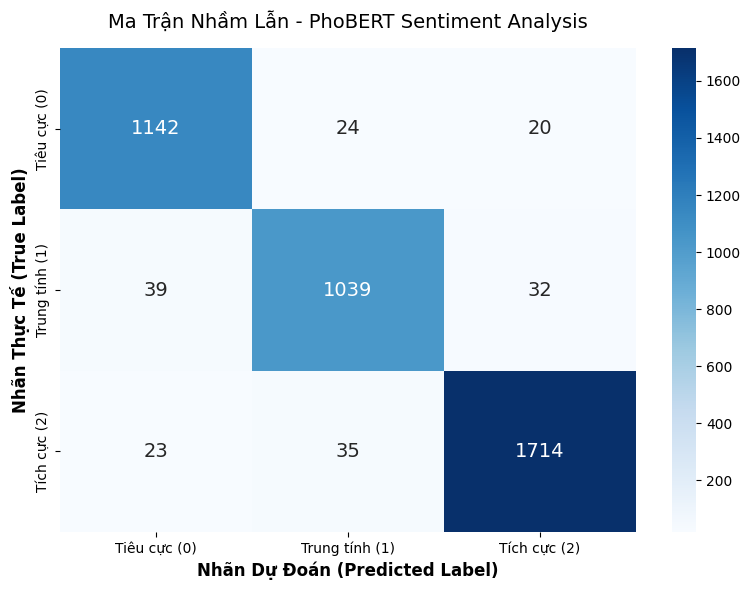

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("Đang chạy dự đoán trên tập Test (Dữ liệu mù)...")

# 1. Lấy dự đoán từ mô hình trên tập Test
predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

# 2. In Báo cáo phân loại chi tiết (Classification Report)
target_names = ['Tiêu cực (0)', 'Trung tính (1)', 'Tích cực (2)']
print("\n" + "="*55)
print("BÁO CÁO PHÂN LOẠI CHI TIẾT (CLASSIFICATION REPORT)")
print("="*55)
print(classification_report(y_true, y_pred, target_names=target_names, digits=4))

# 3. Vẽ biểu đồ Ma trận nhầm lẫn (Confusion Matrix)
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names,
            annot_kws={"size": 14}) # Tăng kích thước chữ số cho dễ nhìn

plt.ylabel('Nhãn Thực Tế (True Label)', fontsize=12, fontweight='bold')
plt.xlabel('Nhãn Dự Đoán (Predicted Label)', fontsize=12, fontweight='bold')
plt.title('Ma Trận Nhầm Lẫn - PhoBERT Sentiment Analysis', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# Hệ thống Phân tích Phản hồi Đa Khía Cạnh (ABSA)

In [5]:
%%writefile app.py
import streamlit as st
import torch
import re
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# 1. Cấu hình giao diện
st.set_page_config(page_title="EduSentiment AI", page_icon="🎓", layout="centered")

st.title("🎓 Hệ thống Phân tích Phản hồi Đa Khía Cạnh (ABSA)")
st.markdown("Đồ án Khai thác dữ liệu & Khám phá tri thức | **Xử lý Cảm xúc Xung đột**")
st.divider()

# 2. Load Model Cảm xúc
@st.cache_resource
def load_model():
    model_path = "./phobert_education_model_final"
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model = AutoModelForSequenceClassification.from_pretrained(model_path)
    return tokenizer, model

tokenizer, model = load_model()

# 3. Hàm Topic (Từ điển cập nhật)
def predict_topic(text):
    text = str(text).lower()
    if any(w in text for w in ['thầy', 'cô', 'giảng viên', 'dạy', 'giảng', 'chấm']):
        return 'Giảng viên 👨‍🏫'
    elif any(w in text for w in ['phòng', 'máy lạnh', 'cơ sở', 'vật chất', 'wifi', 'thiết bị', 'nhà vệ sinh', 'bãi xe', 'thang máy', 'hỏng', 'nóng']):
        return 'Cơ sở vật chất 🏢'
    elif any(w in text for w in ['chương trình', 'môn học', 'đào tạo', 'tín chỉ', 'lịch học', 'đăng ký']):
        return 'Chương trình đào tạo 📚'
    elif any(w in text for w in ['lag', 'lỗi', 'vào', 'màn hình', 'quảng cáo', 'chậm', 'mượt', 'app', 'giao diện']):
        return 'Trải nghiệm ứng dụng 📱'
    elif any(w in text for w in ['từ vựng', 'ngữ pháp', 'giải', 'đáp án', 'bài tập', 'học', 'câu hỏi', 'đúng']):
        return 'Chất lượng học tập 📝'
    else:
        return 'Tổng quan / Khác 🔍'

# 4. Giao diện nhập liệu
# Đã đặt sẵn câu hóc búa của bạn làm ví dụ mặc định!
user_input = st.text_area("✍️ Nhập đánh giá của sinh viên:", value="Thầy dạy rất dễ hiểu nhưng phòng máy lạnh bị hỏng", height=100)

if st.button("🚀 Phân tích Bóc tách (ABSA)", type="primary"):
    if user_input.strip() == "":
        st.warning("Vui lòng nhập nội dung đánh giá trước khi phân tích!")
    else:
        with st.spinner("AI đang bóc tách từng khía cạnh..."):
            from pyvi import ViTokenizer

            # BƯỚC ĐỘT PHÁ: Chặt câu dựa trên các từ nối xung đột hoặc dấu câu
            clauses = re.split(r',|\bnhưng\b|\btuy nhiên\b|\bà\b|\bmà\b|\.', user_input)

            st.success("Phân tích hoàn tất!")
            st.write("### 🔍 Bóc tách chi tiết từng vế câu:")

            labels = ['Tiêu cực 😡', 'Trung tính 😐', 'Tích cực 😍']

            # Phân tích từng vế một
            for clause in clauses:
                clause = clause.strip()
                if len(clause) < 3: # Bỏ qua các vế rác quá ngắn
                    continue

                # Đoán Topic của vế này
                topic = predict_topic(clause)

                # Đoán Sentiment bằng PhoBERT cho riêng vế này
                segmented_text = ViTokenizer.tokenize(clause)
                inputs = tokenizer(segmented_text, return_tensors="pt", truncation=True, max_length=128)

                with torch.no_grad():
                    outputs = model(**inputs)
                    logits = outputs.logits
                    predicted_class = torch.argmax(logits, dim=1).item()
                    sentiment = labels[predicted_class]

                # Hiển thị UI chia khối đẹp mắt cho từng vế
                with st.container():
                    st.markdown(f"**Trích xuất:** *\"{clause.capitalize()}\"*")
                    col1, col2 = st.columns(2)
                    with col1:
                        st.info(f"🏷️ **Khía cạnh:** {topic}")
                    with col2:
                        # Đổi màu cảnh báo tùy theo cảm xúc cho sinh động
                        if predicted_class == 0:
                            st.error(f"🎭 **Cảm xúc:** {sentiment}")
                        elif predicted_class == 2:
                            st.success(f"🎭 **Cảm xúc:** {sentiment}")
                        else:
                            st.warning(f"🎭 **Cảm xúc:** {sentiment}")
                    st.divider()

Writing app.py


# Giao diện hệ thống

In [6]:
# Tải cloudflared nếu chưa có
import os
if not os.path.exists('./cloudflared'):
    !wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
    !chmod +x cloudflared

!pip install streamlit pyvi -q
!pkill -f streamlit
!pkill -f cloudflared
import time

!nohup streamlit run app.py --server.port 8501 > logs.txt 2>&1 &
time.sleep(15)

print("📋 Logs Streamlit:")
!tail -n 5 logs.txt

!nohup ./cloudflared tunnel --url http://localhost:8501 > cloudflared.log 2>&1 &
time.sleep(20)  # ← tăng lên 20 giây

print("\n" + "="*70)
print("🎉 LINK CỦA BẠN:")
print("="*70)
!grep -o 'https://[a-zA-Z0-9\-]*\.trycloudflare\.com' cloudflared.log

# Dự phòng nếu grep không ra
print("\n--- Log thô (nếu link trên trống) ---")
!cat cloudflared.log | tail -20

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 45.9 MB/s eta 0:00:00
📋 Logs Streamlit:

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.230.18.178:8501


🎉 LINK CỦA BẠN:
https://fuzzy-pontiac-asin-england.trycloudflare.com

--- Log thô (nếu link trên trống) ---
2026-05-10T15:38:21Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-05-10T15:38:23Z INF +--------------------------------------------------------------------------------------------+
2026-05-10T15:38:23Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-05-10T15:38:23Z INF |  https://fuzzy-pontiac-asin-england.trycloudflare.com                                      |
2026-05-10T15:38:23Z INF +--------------------------------------------------------------------------------------------+
2026-05-10T15:38:23Z INF Cannot determine 